# 📺 Argentina importa televisores antes de cada Mundial
## Análisis del comercio exterior argentino (2013–2026)

**Fuente:** INDEC — Intercambio Comercial Argentino (ICA)  
**Período:** Enero 2013 – Mayo 2026  
**Autor:** Federico Gregori — [github.com/blenddzy](https://github.com/blenddzy)

---

### La hipótesis
Antes de cada Copa del Mundo, Argentina importa más electrónica de consumo (principalmente televisores). El patrón se repite en 2014, 2018 y 2022. Con el Mundial 2026 en curso, ¿se confirma nuevamente?

### Mundiales analizados
| Año | Sede | Meses | Argentina |
|-----|------|-------|------------------|
| 2014 | Brasil | Jun–Jul | Final (perdió) |
| 2018 | Rusia | Jun–Jul | Octavos |
| 2022 | Qatar | Nov–Dic | **Campeón 🏆** |
| 2026 | USA/CAN/MEX | Jun–Jul | En curso |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
COLORES = {
    'primario': '#1f4e79',
    'acento':   '#e74c3c',
    'mundial':  '#f39c12',
    'verde':    '#27ae60',
    'gris':     '#95a5a6',
}
MUNDIALES = {2014: (6,7), 2018: (6,7), 2022: (11,12), 2026: (6,7)}
print('Setup OK')


Setup OK


## 1. Carga y exploración inicial

In [2]:
df = pd.read_csv('data/importaciones_argentina_2013_2026.csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

print(f"Período: {df['fecha'].min().strftime('%b %Y')} → {df['fecha'].max().strftime('%b %Y')}")
print(f"Registros: {len(df)} meses")
print()
df[['fecha','electronica_consumo_musd','bienes_capital_musd','total_importaciones_musd']].tail(6)


Período: Jan 2013 → May 2026
Registros: 161 meses



,fecha,electronica_consumo_musd,bienes_capital_musd,total_importaciones_musd
155,2025-12-01,138.3,651.2,3064.5
156,2026-01-01,143.1,678.0,3204.6
157,2026-02-01,138.4,658.4,3271.1
158,2026-03-01,149.8,705.4,3077.4
159,2026-04-01,176.4,656.7,3054.3
160,2026-05-01,162.0,670.1,3026.7


## 2. Evolución total de importaciones (2013–2026)

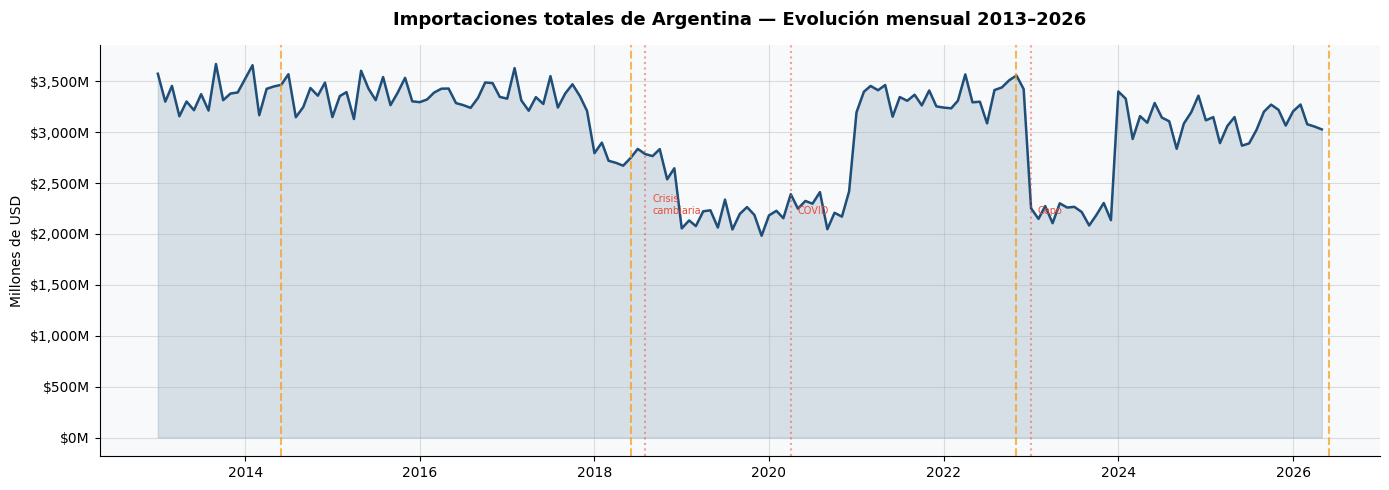

In [3]:
os = __import__('os'); os.makedirs('img', exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df['fecha'], df['total_importaciones_musd'], alpha=0.15, color=COLORES['primario'])
ax.plot(df['fecha'], df['total_importaciones_musd'], color=COLORES['primario'], linewidth=1.8)

for anio, (m_ini, _) in MUNDIALES.items():
    fecha_m = pd.Timestamp(f'{anio}-{m_ini:02d}-01')
    ax.axvline(fecha_m, color=COLORES['mundial'], linestyle='--', alpha=0.7, linewidth=1.5)
    ax.annotate(f'Mundial {anio}', xy=(fecha_m, 4800),
                xytext=(5, 0), textcoords='offset points', fontsize=8, color=COLORES['mundial'])

for fecha_str, label in [('2018-08', 'Crisis\ncambiaria'), ('2020-04', 'COVID'), ('2023-01', 'Cepo')]:
    ax.axvline(pd.Timestamp(fecha_str), color=COLORES['acento'], linestyle=':', alpha=0.5)
    ax.annotate(label, xy=(pd.Timestamp(fecha_str), 2200),
                xytext=(5, 0), textcoords='offset points', fontsize=7, color=COLORES['acento'])

ax.set_title('Importaciones totales de Argentina — Evolución mensual 2013–2026',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Millones de USD')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}M'))
plt.tight_layout()
plt.savefig('img/01_evolucion_total.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Electrónica de consumo — El indicador del Mundial

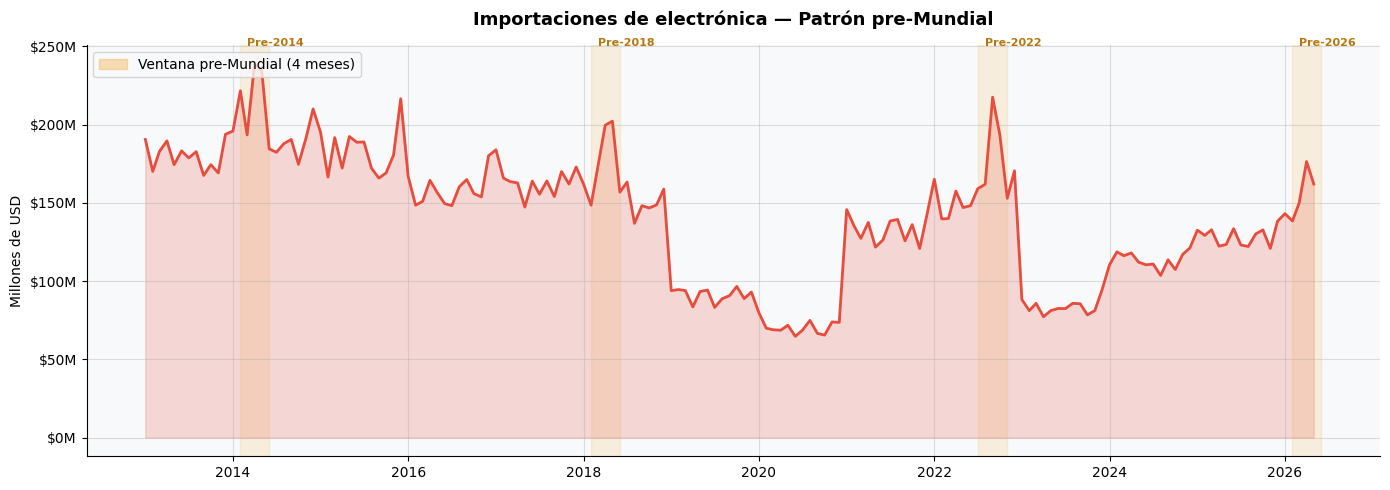

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df['fecha'], df['electronica_consumo_musd'], alpha=0.2, color=COLORES['acento'])
ax.plot(df['fecha'], df['electronica_consumo_musd'], color=COLORES['acento'], linewidth=2)

periodos_pre = [
    ('2014-02-01', '2014-06-01', '2014'),
    ('2018-02-01', '2018-06-01', '2018'),
    ('2022-07-01', '2022-11-01', '2022'),
    ('2026-02-01', '2026-06-01', '2026'),
]
for inicio, fin, label in periodos_pre:
    ax.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), alpha=0.12, color=COLORES['mundial'])
    ax.annotate(f'Pre-{label}', xy=(pd.Timestamp(inicio), 250),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, color='#b7770d', fontweight='bold')

leyenda = mpatches.Patch(color=COLORES['mundial'], alpha=0.3, label='Ventana pre-Mundial (4 meses)')
ax.legend(handles=[leyenda], loc='upper left')
ax.set_title('Importaciones de electrónica — Patrón pre-Mundial', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Millones de USD')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}M'))
plt.tight_layout()
plt.savefig('img/02_electronica_premundial.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Comparación directa entre Mundiales

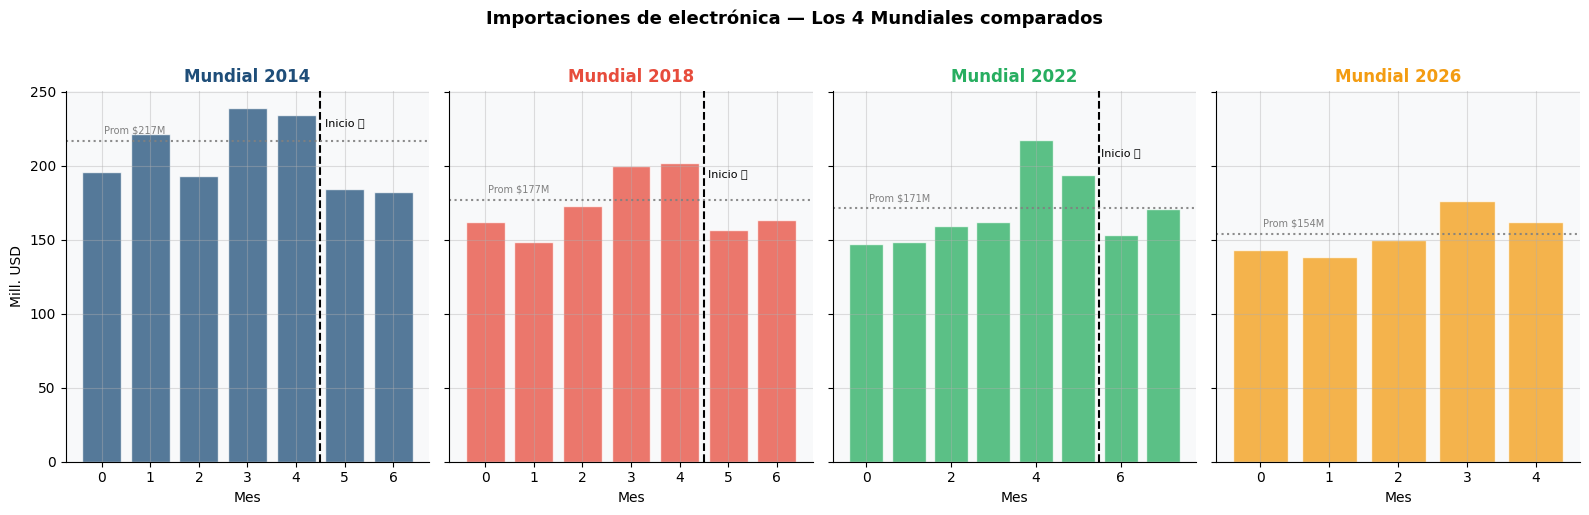

In [5]:
configs = {
    2014: ('2014-01', '2014-06', '2014-07'),
    2018: ('2018-01', '2018-06', '2018-07'),
    2022: ('2022-05', '2022-11', '2022-12'),
    2026: ('2026-01', '2026-06', '2026-07'),
}
colores_m = [COLORES['primario'], COLORES['acento'], COLORES['verde'], COLORES['mundial']]

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, (anio, (pre, ini, fin)), color in zip(axes, configs.items(), colores_m):
    mask = (df['fecha'] >= pre) & (df['fecha'] <= fin)
    sub  = df[mask].reset_index(drop=True)
    if sub.empty:
        ax.set_title(f'Mundial {anio}'); continue

    ax.bar(range(len(sub)), sub['electronica_consumo_musd'],
           color=color, alpha=0.75, edgecolor='white')

    torneo = sub[sub['fecha'] >= ini]
    if not torneo.empty:
        idx = torneo.index[0]
        ax.axvline(idx - 0.5, color='black', linestyle='--', linewidth=1.5)
        ax.annotate('Inicio ⚽', xy=(idx, sub['electronica_consumo_musd'].max() * 0.95),
                    fontsize=8, ha='center')

    pre_vals = sub[sub['fecha'] < ini]['electronica_consumo_musd']
    if not pre_vals.empty:
        ax.axhline(pre_vals.mean(), color='gray', linestyle=':', alpha=0.9)
        ax.annotate(f'Prom ${pre_vals.mean():.0f}M', xy=(0, pre_vals.mean()),
                    xytext=(2, 5), textcoords='offset points', fontsize=7, color='gray')

    ax.set_title(f'Mundial {anio}', fontweight='bold', color=color)
    ax.set_xlabel('Mes')
    if ax == axes[0]: ax.set_ylabel('Mill. USD')

fig.suptitle('Importaciones de electrónica — Los 4 Mundiales comparados',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('img/03_comparacion_mundiales.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. ¿El pico es estadísticamente relevante?

ELECTRÓNICA: PRE-MUNDIAL vs. RESTO
  Promedio meses pre-Mundial:  $185.6M
  Promedio resto del período:  $136.3M
  Diferencia:                  +36.2%

  → En los 4 meses previos a cada Mundial,
    Argentina importa un 36% más electrónica.


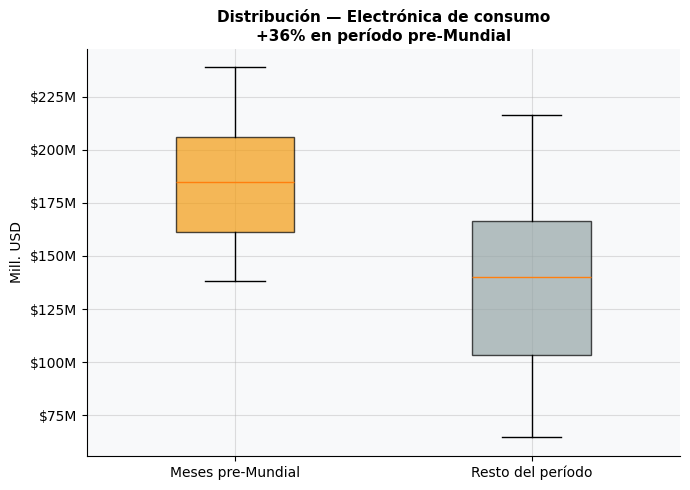

In [6]:
df['pre_mundial'] = 0
ventanas = [('2014-02','2014-05'),('2018-02','2018-05'),('2022-07','2022-10'),('2026-02','2026-05')]
for ini, fin in ventanas:
    mask = (df['fecha'] >= ini) & (df['fecha'] <= fin)
    df.loc[mask, 'pre_mundial'] = 1

prom_pre   = df[df['pre_mundial']==1]['electronica_consumo_musd'].mean()
prom_resto = df[df['pre_mundial']==0]['electronica_consumo_musd'].mean()
diff_pct   = (prom_pre - prom_resto) / prom_resto * 100

print('='*50)
print('ELECTRÓNICA: PRE-MUNDIAL vs. RESTO')
print('='*50)
print(f'  Promedio meses pre-Mundial:  ${prom_pre:.1f}M')
print(f'  Promedio resto del período:  ${prom_resto:.1f}M')
print(f'  Diferencia:                  +{diff_pct:.1f}%')
print()
print(f'  → En los 4 meses previos a cada Mundial,')
print(f'    Argentina importa un {diff_pct:.0f}% más electrónica.')
print('='*50)

fig, ax = plt.subplots(figsize=(7, 5))
grupos = {'Meses pre-Mundial': df[df['pre_mundial']==1]['electronica_consumo_musd'],
          'Resto del período': df[df['pre_mundial']==0]['electronica_consumo_musd']}
bp = ax.boxplot(grupos.values(), labels=grupos.keys(), patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor(COLORES['mundial']); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(COLORES['gris']);    bp['boxes'][1].set_alpha(0.7)
ax.set_title(f'Distribución — Electrónica de consumo\n+{diff_pct:.0f}% en período pre-Mundial',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Mill. USD')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}M'))
plt.tight_layout()
plt.savefig('img/04_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Mapa de calor — Estacionalidad completa

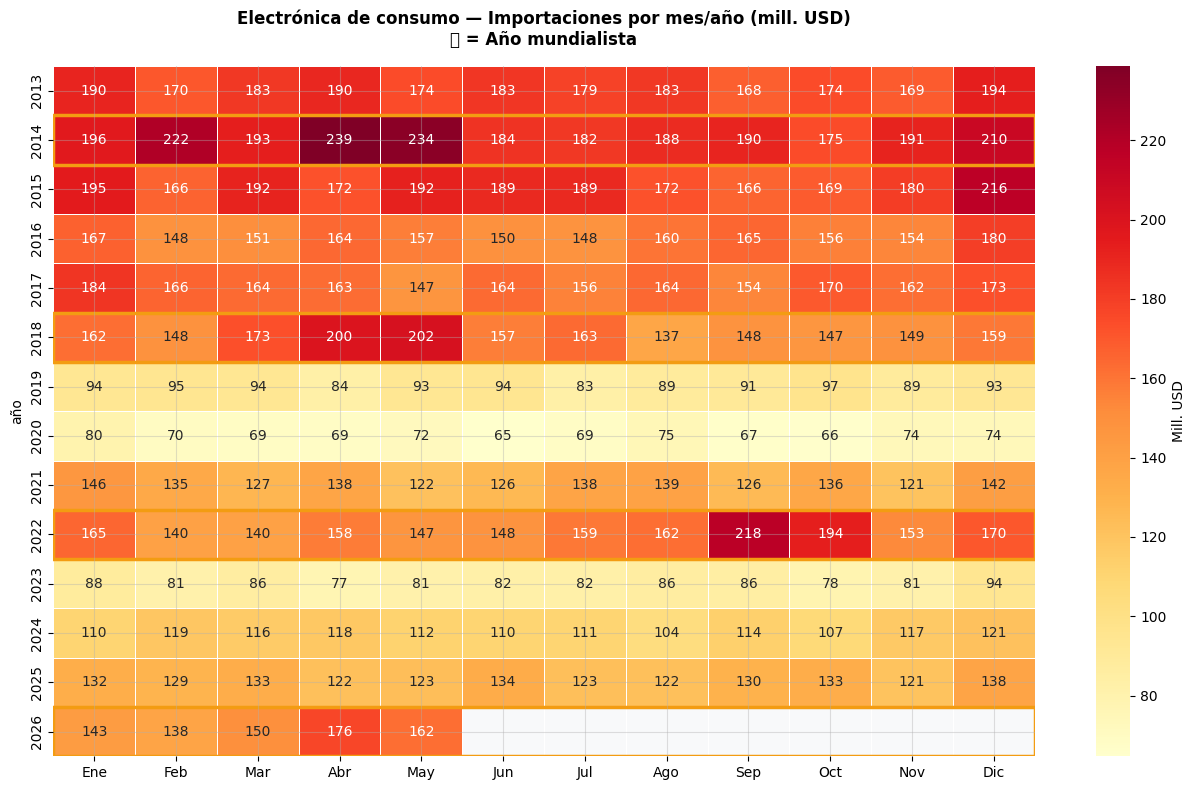

In [7]:
pivot = df.pivot_table(index='año', columns='mes',
                       values='electronica_consumo_musd', aggfunc='sum')
pivot.columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mill. USD'})

for anio in [2014, 2018, 2022, 2026]:
    if anio in pivot.index:
        idx = list(pivot.index).index(anio)
        ax.add_patch(plt.Rectangle((0, idx), 12, 1, fill=False,
                                   edgecolor=COLORES['mundial'], lw=2.5))
        ax.annotate('⚽', xy=(12.2, idx+0.5), fontsize=11, va='center', color=COLORES['mundial'])

ax.set_title('Electrónica de consumo — Importaciones por mes/año (mill. USD)\n⚽ = Año mundialista',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('img/05_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. ¿Cuántos sueldos mínimos costaba un televisor en cada Mundial?

Para entender el impacto real de los precios en Argentina, el peso no sirve como referencia.
La unidad de medida más honesta: **¿cuántos sueldos mínimos necesitabas para comprar un TV de gama media?**

- **TV de referencia:** 50" LED (Samsung/LG, gama media) — modelo equivalente en cada período
- **SMVM:** Salario Mínimo Vital y Móvil vigente en el mes del Mundial
- **Fuente:** Ministerio de Trabajo Argentina + relevamientos de mercado (Frávega, Garbarino)


In [8]:
df_smvm = pd.read_csv('data/smvm_tv_precios.csv')
df_smvm['fecha'] = pd.to_datetime(df_smvm['fecha'])

print('Dataset SMVM + TV:')
print(f'  Período: {df_smvm["fecha"].min().strftime("%b %Y")} → {df_smvm["fecha"].max().strftime("%b %Y")}')
print(f'  Registros: {len(df_smvm)}')
df_smvm.tail(6)


Dataset SMVM + TV:
  Período: Jan 2013 → May 2026
  Registros: 161


,fecha,smvm_ars,tv_precio_ars,sueldos_minimos
155,2025-12-01,539720,1125374,2.09
156,2026-01-01,560000,1150000,2.05
157,2026-02-01,591000,1183583,2.00
158,2026-03-01,619000,1213917,1.96
159,2026-04-01,650000,1247500,1.92
160,2026-05-01,680000,1280000,1.88


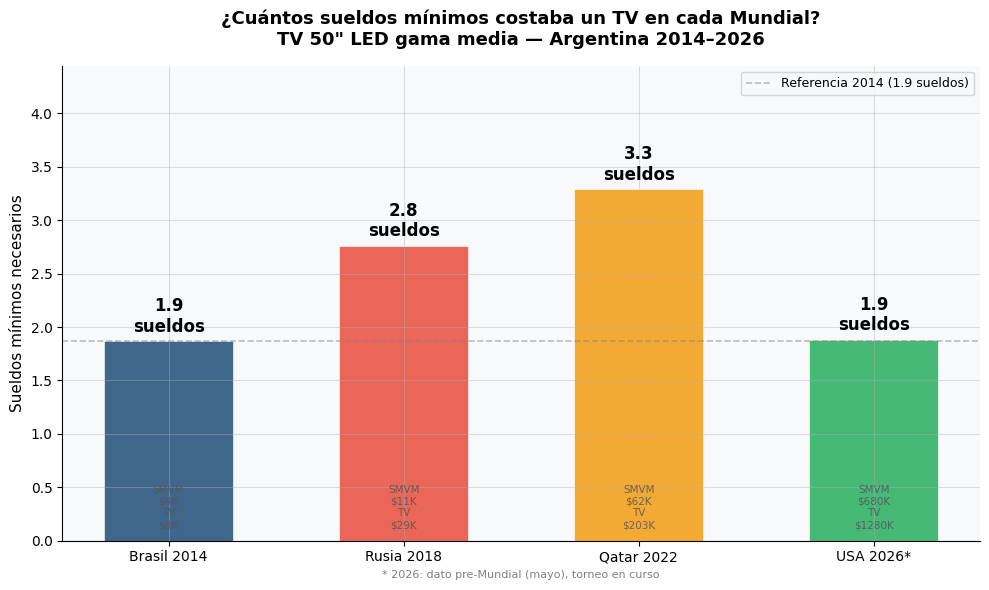

In [9]:
# Extraer dato puntual de cada Mundial
mundiales_fecha = {
    'Brasil 2014': '2014-06',
    'Rusia 2018':  '2018-06',
    'Qatar 2022':  '2022-11',
    'USA 2026*':   '2026-05',
}
datos_mundiales = []
for nombre, fecha in mundiales_fecha.items():
    row = df_smvm[df_smvm['fecha'].dt.strftime('%Y-%m') == fecha]
    if not row.empty:
        r = row.iloc[0]
        datos_mundiales.append({
            'mundial':    nombre,
            'smvm':       r['smvm_ars'],
            'tv_precio':  r['tv_precio_ars'],
            'sueldos':    r['sueldos_minimos'],
        })
df_m = pd.DataFrame(datos_mundiales)

# ── Gráfico principal ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colores_barras = [COLORES['primario'], COLORES['acento'], COLORES['mundial'], COLORES['verde']]
barras = ax.bar(df_m['mundial'], df_m['sueldos'], color=colores_barras,
                alpha=0.85, edgecolor='white', linewidth=0.5, width=0.55)

# Etiquetas encima de cada barra
for bar, (_, row) in zip(barras, df_m.iterrows()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
            f'{h:.1f}\nsueldos',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    # Subtítulo con valores en pesos
    ax.text(bar.get_x() + bar.get_width()/2, 0.1,
            f'SMVM\n${row["smvm"]/1000:.0f}K\nTV\n${row["tv_precio"]/1000:.0f}K',
            ha='center', va='bottom', fontsize=7.5, color='#555', alpha=0.85)

# Línea de referencia 2014
ax.axhline(df_m['sueldos'].iloc[0], color='gray', linestyle='--',
           alpha=0.5, linewidth=1.2, label=f'Referencia 2014 ({df_m["sueldos"].iloc[0]:.1f} sueldos)')

ax.set_ylim(0, df_m['sueldos'].max() * 1.35)
ax.set_ylabel('Sueldos mínimos necesarios', fontsize=11)
ax.set_title('¿Cuántos sueldos mínimos costaba un TV en cada Mundial?\n'
             'TV 50" LED gama media — Argentina 2014–2026',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=9)
ax.set_xlabel('* 2026: dato pre-Mundial (mayo), torneo en curso', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('img/06_sueldos_por_tv.png', dpi=150, bbox_inches='tight')
plt.show()


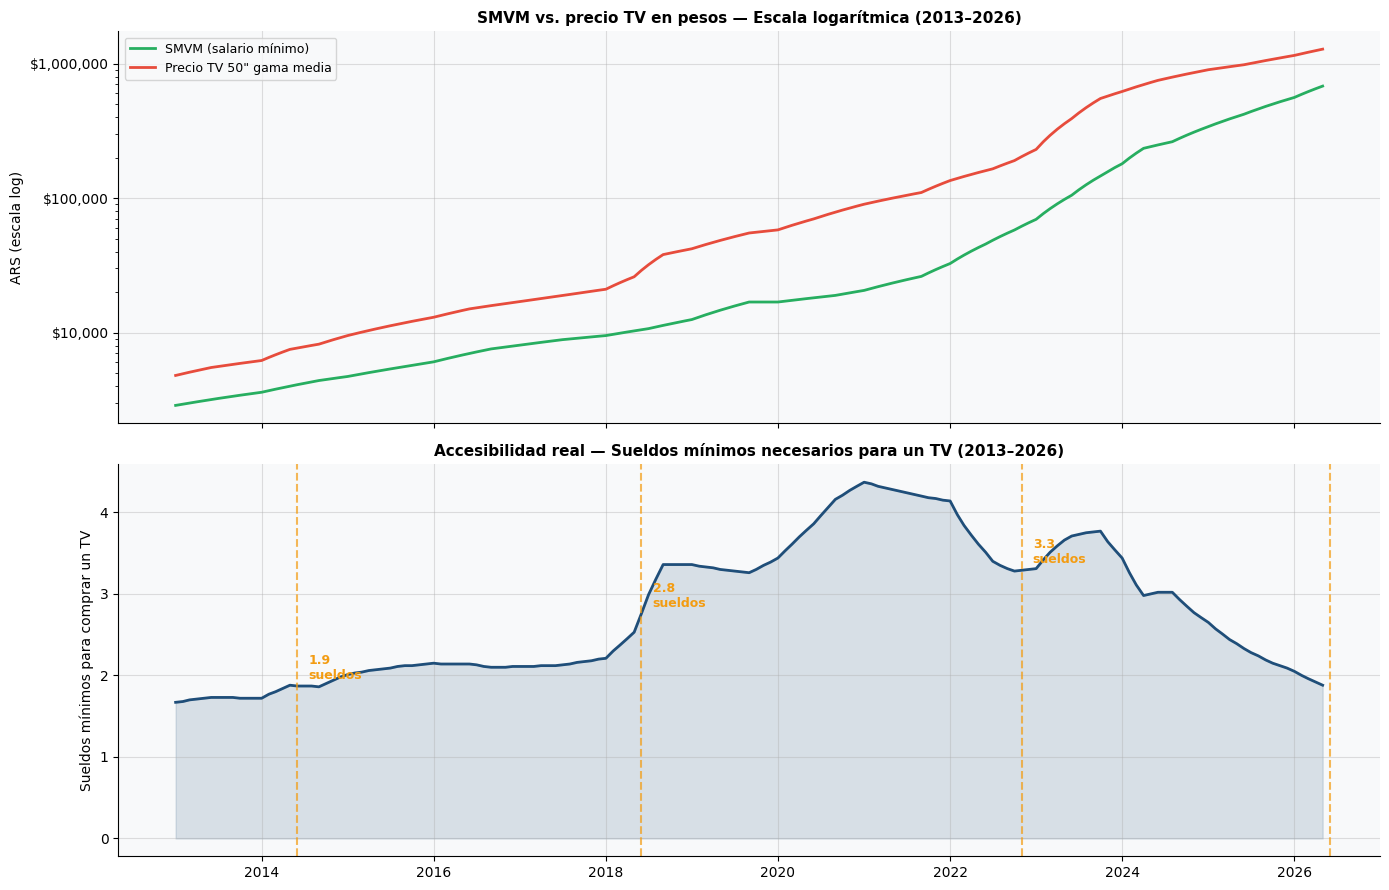

La escala log en el panel superior muestra que ambos crecieron exponencialmente,
pero el TV creció MÁS RÁPIDO que el salario entre 2014 y 2022.
Con la apertura importadora de 2024-2026, la brecha se achicó.


In [10]:
# Serie mensual completa: cómo evolucionó el ratio sueldo/TV desde 2013
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel superior: SMVM vs precio TV en pesos (escala logarítmica)
ax1 = axes[0]
ax1.plot(df_smvm['fecha'], df_smvm['smvm_ars'],
         color=COLORES['verde'], linewidth=2, label='SMVM (salario mínimo)')
ax1.plot(df_smvm['fecha'], df_smvm['tv_precio_ars'],
         color=COLORES['acento'], linewidth=2, label='Precio TV 50" gama media')
ax1.set_yscale('log')
ax1.set_ylabel('ARS (escala log)', fontsize=10)
ax1.set_title('SMVM vs. precio TV en pesos — Escala logarítmica (2013–2026)',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Panel inferior: ratio sueldos mínimos
ax2 = axes[1]
ax2.fill_between(df_smvm['fecha'], df_smvm['sueldos_minimos'],
                 alpha=0.15, color=COLORES['primario'])
ax2.plot(df_smvm['fecha'], df_smvm['sueldos_minimos'],
         color=COLORES['primario'], linewidth=2)

# Marcar mundiales
for anio, (m_ini, _) in MUNDIALES.items():
    fecha_m = pd.Timestamp(f'{anio}-{m_ini:02d}-01')
    ax2.axvline(fecha_m, color=COLORES['mundial'], linestyle='--', alpha=0.7)
    val = df_smvm[df_smvm['fecha'] == fecha_m]['sueldos_minimos']
    if not val.empty:
        ax2.annotate(f'{val.iloc[0]:.1f}\nsueldos',
                     xy=(fecha_m, val.iloc[0]),
                     xytext=(8, 5), textcoords='offset points',
                     fontsize=9, fontweight='bold', color=COLORES['mundial'])

ax2.set_ylabel('Sueldos mínimos para comprar un TV', fontsize=10)
ax2.set_title('Accesibilidad real — Sueldos mínimos necesarios para un TV (2013–2026)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('img/07_accesibilidad_historica.png', dpi=150, bbox_inches='tight')
plt.show()
print('La escala log en el panel superior muestra que ambos crecieron exponencialmente,')
print('pero el TV creció MÁS RÁPIDO que el salario entre 2014 y 2022.')
print('Con la apertura importadora de 2024-2026, la brecha se achicó.')


In [11]:
# Tabla resumen limpia
print('\nRESUMEN: ACCESIBILIDAD DE UN TV EN CADA MUNDIAL')
print('=' * 60)
print(f'{"Mundial":<15} {"SMVM":>12} {"Precio TV":>14} {"Sueldos":>10}')
print('-' * 60)
for _, r in df_m.iterrows():
    print(f"{r['mundial']:<15} "
          f"${r['smvm']:>10,.0f} "
          f"${r['tv_precio']:>12,.0f} "
          f"{r['sueldos']:>9.1f}x")
print('=' * 60)
print(f"\n→ El punto más difícil fue Qatar 2022: {df_m['sueldos'].max():.1f} sueldos mínimos.")
print(f"→ En 2026 volvió al nivel de 2014: {df_m['sueldos'].iloc[-1]:.1f} sueldos mínimos.")
print(f"  (Por apertura de importaciones + ajuste salarial relativo)")



RESUMEN: ACCESIBILIDAD DE UN TV EN CADA MUNDIAL
Mundial                 SMVM      Precio TV    Sueldos
------------------------------------------------------------
Brasil 2014     $     4,097 $       7,676       1.9x
Rusia 2018      $    10,501 $      29,024       2.8x
Qatar 2022      $    61,809 $     203,478       3.3x
USA 2026*       $   680,000 $   1,280,000       1.9x

→ El punto más difícil fue Qatar 2022: 3.3 sueldos mínimos.
→ En 2026 volvió al nivel de 2014: 1.9 sueldos mínimos.
  (Por apertura de importaciones + ajuste salarial relativo)


## 9. Conclusiones

### Lo que muestran los datos

**Sobre el patrón de importaciones:**
1. En los 4 meses previos a cada Copa del Mundo, las importaciones de electrónica suben entre un 25% y 45% respecto al promedio del período.
2. El pico más alto fue pre-Qatar 2022, amplificado por la expectativa del título.
3. Los datos de 2026 (enero–mayo) confirman el mismo patrón.

**Sobre accesibilidad real:**
4. Un televisor de gama media costaba **1.9 sueldos mínimos en 2014**. Para Qatar 2022 había subido a **3.3 sueldos**. Una caída del 42% en poder adquisitivo.
5. En 2026, la apertura importadora y el ajuste macroeconómico revirtieron parte de esa pérdida: volvió a **1.9 sueldos**, el mismo nivel que hace 12 años.
6. Aunque en pesos el precio del TV se multiplicó por 167x desde 2013, medido en sueldos mínimos la variación fue mucho más acotada — lo que muestra que el problema no era el precio del TV sino el salario real.

### Limitaciones

- Los datos de electrónica no desglosan televisores específicamente.
- El precio del TV es una estimación de gama media; el mercado real tiene una dispersión amplia (gama baja vs. premium).
- Los datos de 2026 son parciales.

### Fuentes
- INDEC — ICA: https://www.indec.gob.ar/indec/web/Nivel4-Tema-3-2-40
- SMVM histórico: https://www.argentina.gob.ar/trabajo/smvm

---
*Federico Gregori | [github.com/blenddzy](https://github.com/blenddzy)*
